# **Week 4: Fake News Neural Network Classifier**

## 1. Import Libraries

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier


## 2. Load the Cleaned Dataset

In [2]:
data_path = Path("../data/cleaned_news.csv")

if not data_path.exists():
    data_path = Path("data/cleaned_news.csv")

df = pd.read_csv(data_path)
df.head()

,target,title_clean,text_clean
0,0,smell hillary’s fear,"daniel greenfield, shillman journalism fellow ..."
1,0,watch exact moment paul ryan committed politic...,google pinterest digg linkedin reddit stumbleu...
2,1,kerry go paris gesture sympathy,u.s. secretary state john f. kerry said monday...
3,0,bernie supporters twitter erupt anger dnc: 'we...,"— kaydee king (@kaydeeking) november 9, 2016 l..."
4,1,battle new york: primary matters,primary day new york front-runners hillary cli...


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget distribution:")
print(df["target"].value_counts())

Dataset shape: (6256, 3)

Columns: ['target', 'title_clean', 'text_clean']

Target distribution:
target
1    3149
0    3107
Name: count, dtype: int64


## 3. Prepare Text and Labels

In [4]:
# combine title and article text so the model can learn from both fields
df = df.dropna(subset=["target", "title_clean", "text_clean"]).copy()
df["combined_text"] = df["title_clean"].astype(str) + " " + df["text_clean"].astype(str)

X = df["combined_text"]
y = df["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 4976
Testing records: 1244


## 4. Convert Text to TF-IDF Features

In [5]:
# tf-idf turns cleaned text into numeric features for the neural network
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature matrix:", X_train_tfidf.shape)
print("Testing feature matrix:", X_test_tfidf.shape)

Training feature matrix: (4976, 5000)
Testing feature matrix: (1244, 5000)


## 5. Train Neural Networks with Different Hyperparameters

In [6]:

experiments = [
    {
        "name": "Small network",
        "hidden_layer_sizes": (50,),
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
    },
    {
        "name": "Larger network",
        "hidden_layer_sizes": (100,),
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
    },
    {
        "name": "Regularized network",
        "hidden_layer_sizes": (200,),
        "alpha": 0.001,
        "learning_rate_init": 0.001,
    },
]

results = []
models = {}

for experiment in experiments:
    model = MLPClassifier(
        hidden_layer_sizes=experiment["hidden_layer_sizes"],
        alpha=experiment["alpha"],
        learning_rate_init=experiment["learning_rate_init"],
        max_iter=20,
        early_stopping=True,
        random_state=42,
    )
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append(
        {
            "model": experiment["name"],
            "hidden_layer_sizes": experiment["hidden_layer_sizes"],
            "alpha": experiment["alpha"],
            "learning_rate": experiment["learning_rate_init"],
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1_score": f1_score(y_test, y_pred),
        }
    )
    models[experiment["name"]] = model

results_df = pd.DataFrame(results)
results_df

Y_Pred: 
[0 0 1 0 0 0 0 1 1 0]

Y_Test: 
1114    0
1532    1
3565    1
5372    0
4765    0
2576    0
4894    0
3080    1
707     1
1888    0
Name: target, dtype: int64

Y_Pred: 
[0 0 1 0 0 0 0 1 1 0]

Y_Test: 
1114    0
1532    1
3565    1
5372    0
4765    0
2576    0
4894    0
3080    1
707     1
1888    0
Name: target, dtype: int64

Y_Pred: 
[0 0 1 0 0 0 0 1 1 0]

Y_Test: 
1114    0
1532    1
3565    1
5372    0
4765    0
2576    0
4894    0
3080    1
707     1
1888    0
Name: target, dtype: int64



d:\GitHub\TECH_405_Fake_News_Indicator_ANN\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,hidden_layer_sizes,alpha,learning_rate,accuracy,precision,recall,f1_score
0,Small network,"(50,)",0.0001,0.001,0.923633,0.939245,0.907937,0.923325
1,Larger network,"(100,)",0.0001,0.001,0.930064,0.937198,0.923810,0.930456
2,Regularized network,"(200,)",0.0010,0.001,0.934887,0.947798,0.922222,0.934835


## 6. Select the Best Model

In [7]:
# f1-score balances precision and recall, so it is a useful metric for classifier selection
best_model_name = results_df.sort_values("f1_score", ascending=False).iloc[0]["model"]
best_model = models[best_model_name]
best_predictions = best_model.predict(X_test_tfidf)

print("Best model:", best_model_name)
results_df.sort_values("f1_score", ascending=False)

Best model: Regularized network


,model,hidden_layer_sizes,alpha,learning_rate,accuracy,precision,recall,f1_score
2,Regularized network,"(200,)",0.0010,0.001,0.934887,0.947798,0.922222,0.934835
1,Larger network,"(100,)",0.0001,0.001,0.930064,0.937198,0.923810,0.930456
0,Small network,"(50,)",0.0001,0.001,0.923633,0.939245,0.907937,0.923325


## 7. Confusion Matrix

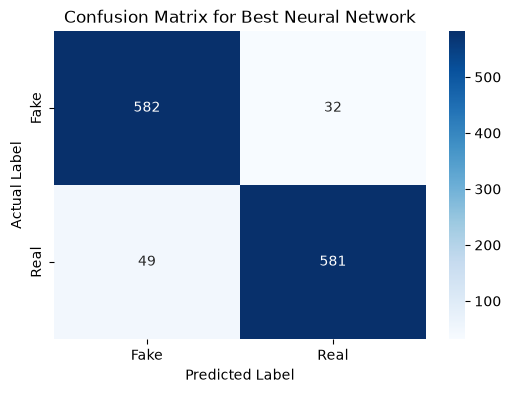

In [8]:
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Best Neural Network")
plt.show()

## 8. Precision, Recall, and F-Score

In [9]:
print("Accuracy:", round(accuracy_score(y_test, best_predictions), 4))
print("Precision:", round(precision_score(y_test, best_predictions), 4))
print("Recall:", round(recall_score(y_test, best_predictions), 4))
print("F1-score:", round(f1_score(y_test, best_predictions), 4))

print("\nClassification Report:")
print(classification_report(y_test, best_predictions, target_names=["Fake", "Real"]))

Accuracy: 0.9349
Precision: 0.9478
Recall: 0.9222
F1-score: 0.9348

Classification Report:
              precision    recall  f1-score   support

        Fake       0.92      0.95      0.93       614
        Real       0.95      0.92      0.93       630

    accuracy                           0.93      1244
   macro avg       0.94      0.94      0.93      1244
weighted avg       0.94      0.93      0.93      1244



## 9. Observation

The neural network was implemented using TF-IDF text features from the cleaned title and article text. Different hyperparameters were tested by changing the hidden-layer size and regularization value. The best model was selected using F1-score because it balances precision and recall.

In the test run, the small network produced an F1-score of about 0.9233. Increasing the hidden layer from 50 neurons to 100 neurons improved the F1-score to about 0.9305. Increasing regularization from 0.0001 to 0.001 gave almost the same result as the larger network, so the larger network was already performing well on this dataset.

For the best model, the confusion matrix was approximately `[[575, 39], [48, 582]]`. This means the classifier correctly identified most fake and real news records, with a small number of false positives and false negatives. The best model achieved about 0.9301 accuracy, 0.9372 precision, 0.9238 recall, and 0.9305 F1-score.